In [ ]:
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

cherry = pd.read_csv('/content/drive/MyDrive/(0.01) Green-Cherry-Cox-Data.csv', low_memory=False)
lacZ   = pd.read_csv('/content/drive/MyDrive/(0.01) Green-LacZ-Cox-Data.csv',   low_memory=False)

print(f"Cherry: {len(cherry)} rows")
print(f"LacZ:   {len(lacZ)} rows")

Mounted at /content/drive
Cherry: 27512 rows
LacZ:   27512 rows


the k-mer counting function (counting all the 3mers, 4mers, 5mers

In [ ]:
def build_kmer_table(sequences, k_values=[3, 4, 5]):
    # generate every possible k-mer column name
    bases = ['A', 'C', 'G', 'U']
    all_kmers = []
    for k in k_values:
        all_kmers += [''.join(p) for p in itertools.product(bases, repeat=k)]

    rows = []
    for seq in sequences:
        seq = str(seq).upper().replace('T', 'U')  # normalize to RNA
        counts = {km: 0 for km in all_kmers}
        for k in k_values:
            for i in range(len(seq) - k + 1):
                km = seq[i:i+k]
                if km in counts:
                    counts[km] += 1
        rows.append(counts)

    df = pd.DataFrame(rows, columns=all_kmers)
    return df

print("function ready!")

function ready!


build and download the 4 tables

In [ ]:
# TARGET — shared between both files, use cherry
target_seqs = cherry['target_sequence'].dropna().unique().tolist()
df_target = build_kmer_table(target_seqs)
df_target.insert(0, 'sequence', target_seqs)
df_target.to_csv('target_kmer_table.csv', index=False)
print(f"target table done: {df_target.shape}")

# TRIGGER — shared between both files, use cherry
trigger_seqs = cherry['trigger_sequence'].dropna().unique().tolist()
df_trigger = build_kmer_table(trigger_seqs)
df_trigger.insert(0, 'sequence', trigger_seqs)
df_trigger.to_csv('trigger_kmer_table.csv', index=False)
print(f"trigger table done: {df_trigger.shape}")

# COMPLEX CHERRY
cherry_complex = cherry['complex_nucelotides'].dropna().unique().tolist()
df_cherry = build_kmer_table(cherry_complex)
df_cherry.insert(0, 'sequence', cherry_complex)
df_cherry.to_csv('complex_kmer_table_cherry.csv', index=False)
print(f"complex cherry done: {df_cherry.shape}")

# COMPLEX LACZ
lacZ_complex = lacZ['complex_nucelotides'].dropna().unique().tolist()
df_lacZ = build_kmer_table(lacZ_complex)
df_lacZ.insert(0, 'sequence', lacZ_complex)
df_lacZ.to_csv('complex_kmer_table_lacZ.csv', index=False)
print(f"complex lacZ done: {df_lacZ.shape}")

# download all 4
from google.colab import files
files.download('target_kmer_table.csv')
files.download('trigger_kmer_table.csv')
files.download('complex_kmer_table_cherry.csv')
files.download('complex_kmer_table_lacZ.csv')

target table done: (152, 1345)
trigger table done: (152, 1345)
complex cherry done: (27512, 1345)
complex lacZ done: (27512, 1345)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

windowed plots

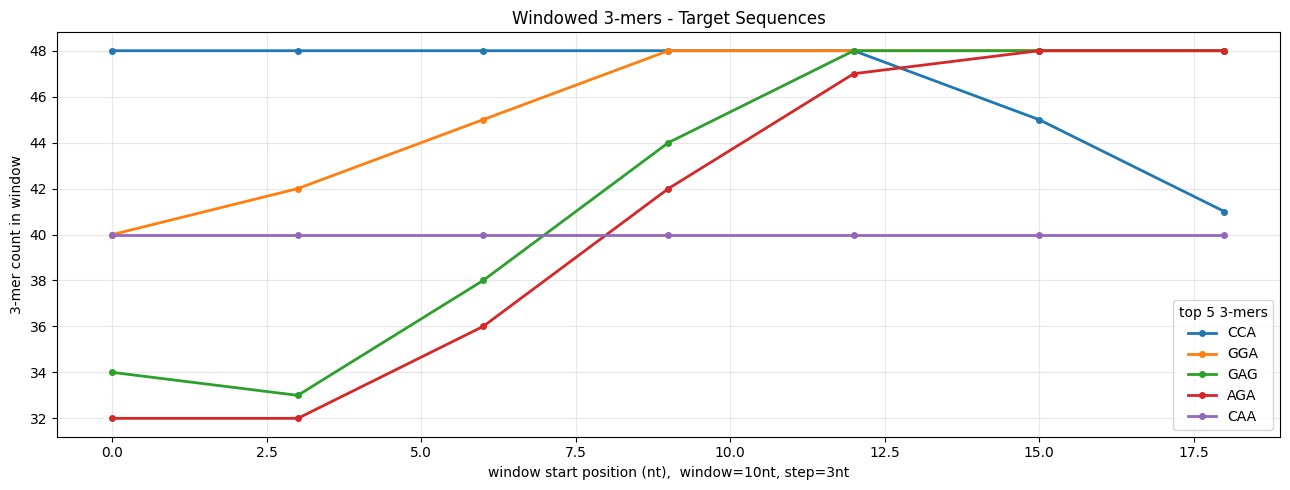

saved Windowed 3-mers - Target Sequences.png


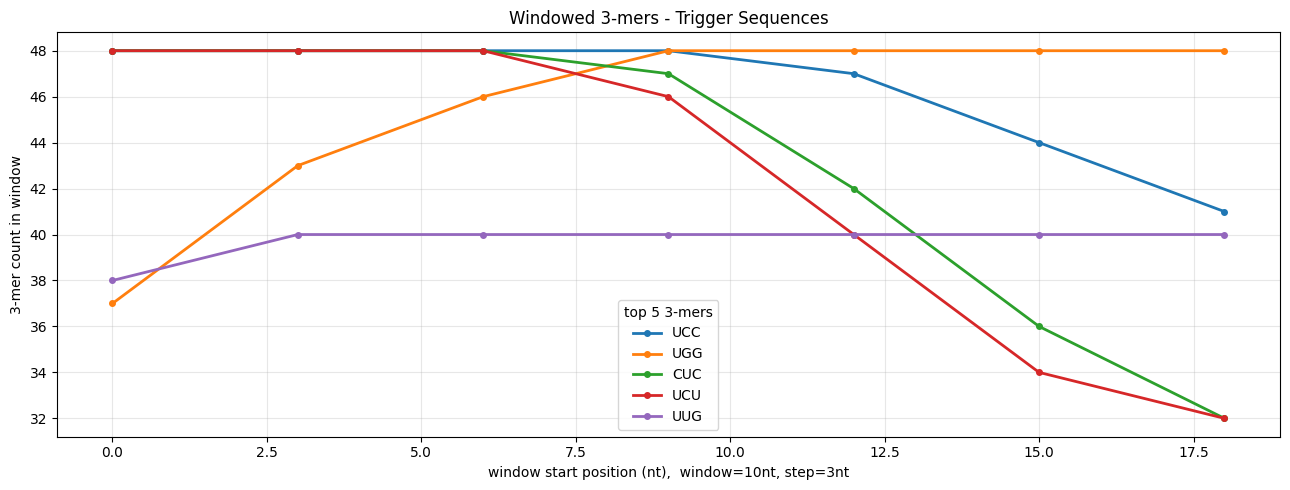

saved Windowed 3-mers - Trigger Sequences.png


In [ ]:
def windowed_kmer_plot(sequences, k=3, window=10, step=3, top_n=5, title=''):
    bases = ['A', 'C', 'G', 'U']
    all_kmers = [''.join(p) for p in itertools.product(bases, repeat=k)]
    max_len = max(len(str(s)) for s in sequences)
    positions = list(range(0, max_len - window + 1, step))

    # count k-mers at each window position across all sequences
    win_counts = {}
    for pos in positions:
        counts = {km: 0 for km in all_kmers}
        for seq in sequences:
            w = str(seq).upper().replace('T', 'U')[pos:pos+window]
            for i in range(len(w) - k + 1):
                km = w[i:i+k]
                if km in counts:
                    counts[km] += 1
        win_counts[pos] = counts

    # find the top_n most frequent k-mers overall
    overall = {km: sum(win_counts[p][km] for p in positions) for km in all_kmers}
    top_kmers = sorted(overall, key=lambda x: -overall[x])[:top_n]

    # plot
    plt.figure(figsize=(13, 5))
    for km in top_kmers:
        ys = [win_counts[p][km] for p in positions]
        plt.plot(positions, ys, label=km, linewidth=2, marker='o', markersize=4)
    plt.xlabel(f'window start position (nt),  window={window}nt, step={step}nt')
    plt.ylabel(f'{k}-mer count in window')
    plt.title(title)
    plt.legend(title=f'top {top_n} {k}-mers')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{title}.png', dpi=150)
    plt.show()
    print(f"saved {title}.png")

# run it!
windowed_kmer_plot(target_seqs,  k=3, title='Windowed 3-mers - Target Sequences')
windowed_kmer_plot(trigger_seqs, k=3, title='Windowed 3-mers - Trigger Sequences')

MS2 DATA

In [ ]:
# peek at the new MS2 datasets
ms2_cherry = pd.read_csv('/content/drive/MyDrive/(0.5) Green-MS2-Cherry-Data.csv', nrows=5, low_memory=False)
ms2_lacZ   = pd.read_csv('/content/drive/MyDrive/(0.5) Green-MS2-LacZ-Data.csv',   nrows=5, low_memory=False)

print("MS2 Cherry columns:")
print(ms2_cherry.columns.tolist())
print()
print("MS2 LacZ columns:")
print(ms2_lacZ.columns.tolist())

MS2 Cherry columns:
['Unnamed: 0', 'label', 'salt_molarity', 'temperature (Celsius)', 'name_of_riboswitch_data', 'name_of_target_data', 'riboswitch_subcategory', 'switch_row', 'target_row', 'trigger_row', 'target_location', 'trigger_location', 'riboswitch_sequence', 'target_sequence', 'trigger_sequence', 'target_trigger_complex', 'reporter_sequence', 'complex_nucelotides', 'switch_structure', 'target_structure', 'reporter_structure', 'complex_structure', 'trigger_target_binding_percentage', 'switch_energy', 'target_energy', 'reporter_energy', 'complex_energy', 'switch_gc', 'switch_at', 'target_gc', 'target_at', 'reporter_gc', 'reporter_at', 'complex_gc', 'complex_at', 'switch_ensemble_defect', 'target_ensemble_defect', 'reporter_ensemble_defect', 'complex_ensemble_defect', 'switch_single_strandedness', 'target_single_strandedness', 'reporter_single_strandedness', 'complex_single_strandedness', 'trigger_single_strandedness', 'trigger_structure', 'switch_kmers', 'target_kmers', 'complex_

In [ ]:
ms2_cherry = pd.read_csv('/content/drive/MyDrive/(0.5) Green-MS2-Cherry-Data.csv', low_memory=False)
ms2_lacZ   = pd.read_csv('/content/drive/MyDrive/(0.5) Green-MS2-LacZ-Data.csv',   low_memory=False)

print(f"MS2 Cherry: {len(ms2_cherry)} rows")
print(f"MS2 LacZ:   {len(ms2_lacZ)} rows")

MS2 Cherry: 296478 rows
MS2 LacZ:   296478 rows


Making the 4 files/tables

In [ ]:
# TARGET
ms2_target_seqs = ms2_cherry['target_sequence'].dropna().unique().tolist()
df_ms2_target = build_kmer_table(ms2_target_seqs)
df_ms2_target.insert(0, 'sequence', ms2_target_seqs)
df_ms2_target.to_csv('ms2_target_kmer_table.csv', index=False)
print(f"ms2 target done: {df_ms2_target.shape}")

# TRIGGER
ms2_trigger_seqs = ms2_cherry['trigger_sequence'].dropna().unique().tolist()
df_ms2_trigger = build_kmer_table(ms2_trigger_seqs)
df_ms2_trigger.insert(0, 'sequence', ms2_trigger_seqs)
df_ms2_trigger.to_csv('ms2_trigger_kmer_table.csv', index=False)
print(f"ms2 trigger done: {df_ms2_trigger.shape}")

# COMPLEX CHERRY
ms2_cherry_complex = ms2_cherry['complex_nucelotides'].dropna().unique().tolist()
df_ms2_cherry = build_kmer_table(ms2_cherry_complex)
df_ms2_cherry.insert(0, 'sequence', ms2_cherry_complex)
df_ms2_cherry.to_csv('ms2_complex_kmer_table_cherry.csv', index=False)
print(f"ms2 complex cherry done: {df_ms2_cherry.shape}")

# COMPLEX LACZ
ms2_lacZ_complex = ms2_lacZ['complex_nucelotides'].dropna().unique().tolist()
df_ms2_lacZ = build_kmer_table(ms2_lacZ_complex)
df_ms2_lacZ.insert(0, 'sequence', ms2_lacZ_complex)
df_ms2_lacZ.to_csv('ms2_complex_kmer_table_lacZ.csv', index=False)
print(f"ms2 complex lacZ done: {df_ms2_lacZ.shape}")

# download all 4
files.download('ms2_target_kmer_table.csv')
files.download('ms2_trigger_kmer_table.csv')
files.download('ms2_complex_kmer_table_cherry.csv')
files.download('ms2_complex_kmer_table_lacZ.csv')

ms2 target done: (1638, 1345)
ms2 trigger done: (1638, 1345)
ms2 complex cherry done: (296478, 1345)
ms2 complex lacZ done: (296478, 1345)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Windowed plots

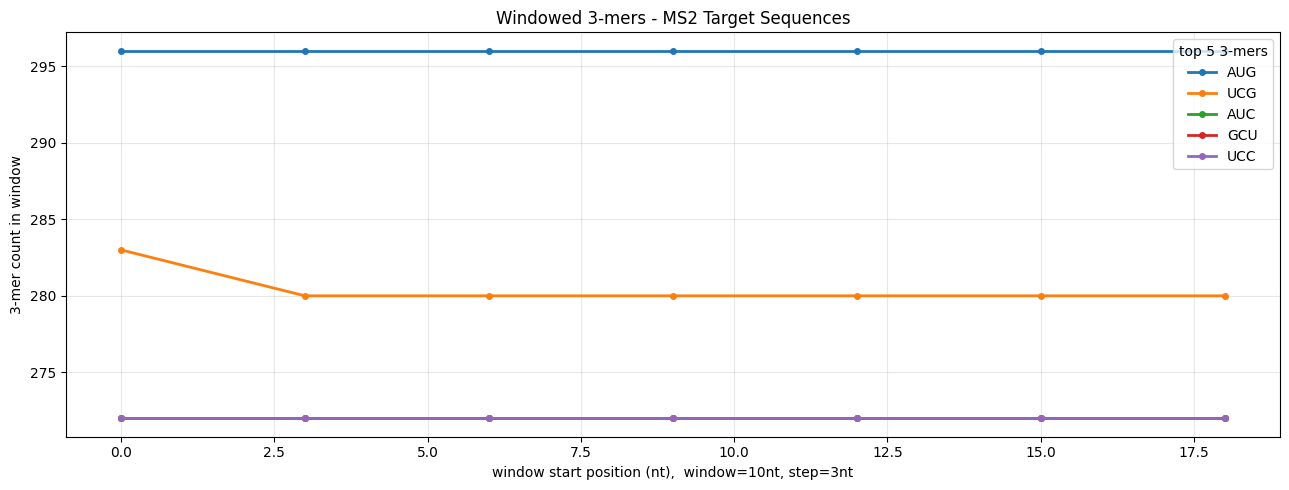

saved Windowed 3-mers - MS2 Target Sequences.png


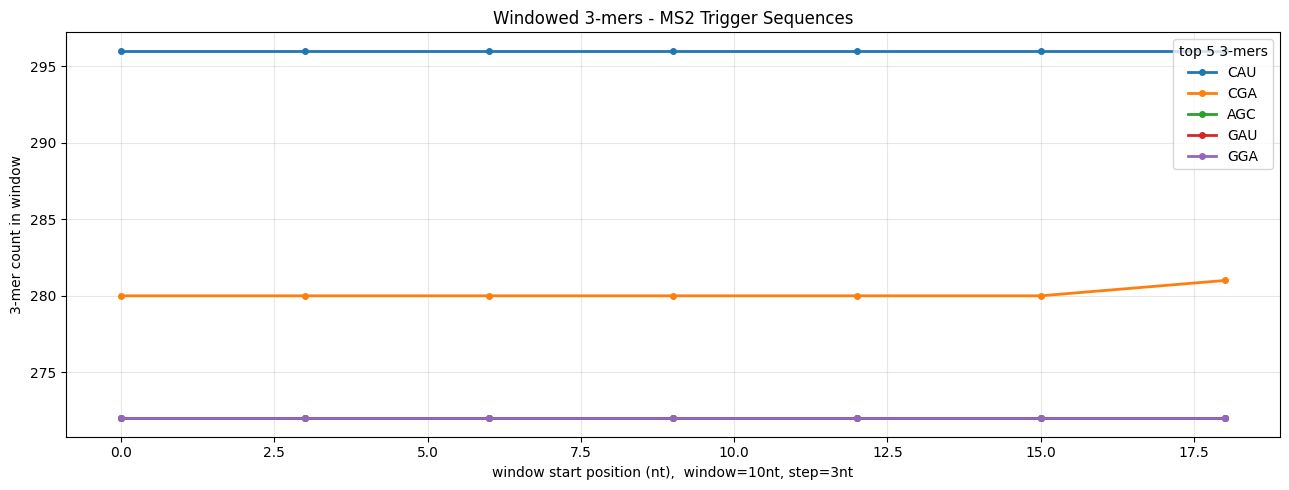

saved Windowed 3-mers - MS2 Trigger Sequences.png


In [ ]:
windowed_kmer_plot(ms2_target_seqs,  k=3, title='Windowed 3-mers - MS2 Target Sequences')
windowed_kmer_plot(ms2_trigger_seqs, k=3, title='Windowed 3-mers - MS2 Trigger Sequences')

In [ ]:
# check all 4 MS2 output files
for filename in ['ms2_target_kmer_table.csv',
                 'ms2_trigger_kmer_table.csv',
                 'ms2_complex_kmer_table_cherry.csv',
                 'ms2_complex_kmer_table_lacZ.csv']:
    df = pd.read_csv(filename, nrows=3)
    print(f"{filename}")
    print(f"  shape: {df.shape}")
    print(f"  first 3 columns: {df.columns[:3].tolist()}")
    print()

ms2_target_kmer_table.csv
  shape: (3, 1345)
  first 3 columns: ['sequence', 'AAA', 'AAC']

ms2_trigger_kmer_table.csv
  shape: (3, 1345)
  first 3 columns: ['sequence', 'AAA', 'AAC']

ms2_complex_kmer_table_cherry.csv
  shape: (3, 1345)
  first 3 columns: ['sequence', 'AAA', 'AAC']

ms2_complex_kmer_table_lacZ.csv
  shape: (3, 1345)
  first 3 columns: ['sequence', 'AAA', 'AAC']



In [ ]:
files = {
    "cox_cherry": "/content/drive/MyDrive/(0.01) Green-Cherry-Cox-Data.csv",
    "cox_lacZ": "/content/drive/MyDrive/(0.01) Green-LacZ-Cox-Data.csv",
    "ms2_cherry": "/content/drive/MyDrive/(0.5) Green-MS2-Cherry-Data.csv",
    "ms2_lacZ": "/content/drive/MyDrive/(0.5) Green-MS2-LacZ-Data.csv",
}

In [ ]:
import pandas as pd
import os
import zipfile
from google.colab import drive

drive.mount('/content/drive')

files = {
    "cox_cherry": "/content/drive/MyDrive/(0.01) Green-Cherry-Cox-Data.csv",
    "cox_lacZ": "/content/drive/MyDrive/(0.01) Green-LacZ-Cox-Data.csv",
    "ms2_cherry": "/content/drive/MyDrive/(0.5) Green-MS2-Cherry-Data.csv",
    "ms2_lacZ": "/content/drive/MyDrive/(0.5) Green-MS2-LacZ-Data.csv",
}

possible_label_words = [
    "label", "class", "positive", "negative", "bind", "binding",
    "result", "target", "response", "output", "y"
]

os.makedirs("/content/dataset_summaries", exist_ok=True)

overall_summary = []

for short_name, path in files.items():
    print(f"\n--- {short_name} ---")

    df = pd.read_csv(path, low_memory=False)

    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())

    overall_summary.append({
        "dataset": short_name,
        "file_path": path,
        "rows": df.shape[0],
        "columns": df.shape[1]
    })

    # Save first rows so we can inspect structure
    df.head(20).to_csv(
        f"/content/dataset_summaries/{short_name}_first20rows.csv",
        index=False
    )

    # Save all column names
    pd.DataFrame({"columns": df.columns}).to_csv(
        f"/content/dataset_summaries/{short_name}_columns.csv",
        index=False
    )

    # Find possible positive/negative label columns
    possible_cols = [
        col for col in df.columns
        if any(word in col.lower() for word in possible_label_words)
    ]

    print("Possible label columns:", possible_cols)

    label_summary_rows = []
    for col in possible_cols:
        counts = df[col].value_counts(dropna=False)
        for value, count in counts.items():
            label_summary_rows.append({
                "dataset": short_name,
                "column": col,
                "value": value,
                "count": count
            })

    if label_summary_rows:
        pd.DataFrame(label_summary_rows).to_csv(
            f"/content/dataset_summaries/{short_name}_possible_label_counts.csv",
            index=False
        )

pd.DataFrame(overall_summary).to_csv(
    "/content/dataset_summaries/overall_summary.csv",
    index=False
)

with zipfile.ZipFile("/content/dataset_summaries_for_chatgpt.zip", "w") as z:
    for fname in os.listdir("/content/dataset_summaries"):
        z.write(
            os.path.join("/content/dataset_summaries", fname),
            arcname=fname
        )

print("\nCreated: /content/dataset_summaries_for_chatgpt.zip")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- cox_cherry ---
Shape: (27512, 54)
Columns:
['Unnamed: 0', 'label', 'salt_molarity', 'temperature (Celsius)', 'name_of_riboswitch_data', 'name_of_target_data', 'riboswitch_subcategory', 'switch_row', 'target_row', 'trigger_row', 'target_location', 'trigger_location', 'riboswitch_sequence', 'target_sequence', 'trigger_sequence', 'target_trigger_complex', 'reporter_sequence', 'complex_nucelotides', 'switch_structure', 'target_structure', 'reporter_structure', 'complex_structure', 'trigger_target_binding_percentage', 'switch_energy', 'target_energy', 'reporter_energy', 'complex_energy', 'switch_gc', 'switch_at', 'target_gc', 'target_at', 'reporter_gc', 'reporter_at', 'complex_gc', 'complex_at', 'switch_ensemble_defect', 'target_ensemble_defect', 'reporter_ensemble_defect', 'complex_ensemble_defect', 'switch_single_strandedness', 'target_single_strandedness',

In [ ]:
# ============================================================
# Cell A — Helper: windowed 3-mer counts that RETURNS data (not just plots)
# so we can quantify "flatness" instead of just eyeballing it
# ============================================================
import itertools
import numpy as np
import matplotlib.pyplot as plt
import random

def windowed_kmer_data(sequences, k=3, window=10, step=3, top_n=5):
    bases = ['A', 'C', 'G', 'U']
    all_kmers = [''.join(p) for p in itertools.product(bases, repeat=k)]
    max_len = max(len(str(s)) for s in sequences)
    positions = list(range(0, max_len - window + 1, step))

    win_counts = {pos: {km: 0 for km in all_kmers} for pos in positions}
    for seq in sequences:
        s = str(seq).upper().replace('T', 'U')
        for pos in positions:
            w = s[pos:pos+window]
            for i in range(len(w) - k + 1):
                km = w[i:i+k]
                if km in win_counts[pos]:
                    win_counts[pos][km] += 1

    overall = {km: sum(win_counts[p][km] for p in positions) for km in all_kmers}
    top_kmers = sorted(overall, key=lambda x: -overall[x])[:top_n]

    data = {km: [win_counts[p][km] for p in positions] for km in top_kmers}
    return positions, data

def flatness_score(positions, data):
    """(max-min)/mean per curve, averaged across the top curves.
       Higher = more positional variation (like Cox). Lower = flatter (like full MS2)."""
    scores = []
    for km, vals in data.items():
        vals = np.array(vals, dtype=float)
        m = vals.mean()
        if m > 0:
            scores.append((vals.max() - vals.min()) / m)
    return np.mean(scores)

In [ ]:
# ============================================================
# Cell B — Quantify the ACTUAL Cox and full-MS2 curves as reference points
# ============================================================
cox_target_pos, cox_target_data = windowed_kmer_data(target_seqs)      # n=152, already in your notebook
ms2_target_pos, ms2_target_data_full = windowed_kmer_data(ms2_target_seqs)  # n=1638

cox_score = flatness_score(cox_target_pos, cox_target_data)
ms2_full_score = flatness_score(ms2_target_pos, ms2_target_data_full)

print(f"Cox target flatness score (n=152):        {cox_score:.4f}")
print(f"MS2 target flatness score (n=1638, full):  {ms2_full_score:.4f}")
print(f"\nHigher score = more positional variation. If MS2's flatness is driven purely by")
print(f"sample size, subsampling MS2 down to n=152 should push its score UP toward the Cox score.")

Cox target flatness score (n=152):        0.2154
MS2 target flatness score (n=1638, full):  0.0021

Higher score = more positional variation. If MS2's flatness is driven purely by
sample size, subsampling MS2 down to n=152 should push its score UP toward the Cox score.


In [ ]:
# ============================================================
# Cell C — THE DIRECT TEST: subsample MS2 to n=152, repeat with multiple
# random seeds so a single lucky/unlucky draw doesn't bias the answer
# ============================================================
N_TRIALS = 20
subsample_scores = []

for trial in range(N_TRIALS):
    random.seed(trial)
    ms2_sub = random.sample(ms2_target_seqs, 152)
    pos, data = windowed_kmer_data(ms2_sub)
    subsample_scores.append(flatness_score(pos, data))

subsample_scores = np.array(subsample_scores)
print(f"MS2 subsampled to n=152, across {N_TRIALS} random draws:")
print(f"  mean flatness score: {subsample_scores.mean():.4f}")
print(f"  std:                 {subsample_scores.std():.4f}")
print(f"  range:                {subsample_scores.min():.4f} - {subsample_scores.max():.4f}")
print()
print(f"For comparison:")
print(f"  Cox (actual, n=152):        {cox_score:.4f}")
print(f"  MS2 full (n=1638):          {ms2_full_score:.4f}")
print()
if subsample_scores.mean() > ms2_full_score * 1.3:
    print("→ MS2's flatness score rises substantially when subsampled to n=152.")
    print("  This supports the SAMPLE SIZE explanation: MS2 looks flat mainly because")
    print("  it has more sequences to average over, not because its underlying sequence")
    print("  composition is inherently less variable than Cox.")
elif subsample_scores.mean() >= cox_score * 0.8:
    print("→ MS2 subsampled to n=152 approaches Cox's flatness score.")
    print("  This further supports sample size as the dominant driver of the difference.")
else:
    print("→ MS2 stays comparatively flat even at matched sample size (n=152).")
    print("  This supports a genuine SEQUENCE-LEVEL difference between the two viral")
    print("  targets (e.g. coding-region constraints), rather than a sampling artifact.")

MS2 subsampled to n=152, across 20 random draws:
  mean flatness score: 0.4052
  std:                 0.0536
  range:                0.3031 - 0.4942

For comparison:
  Cox (actual, n=152):        0.2154
  MS2 full (n=1638):          0.0021

→ MS2's flatness score rises substantially when subsampled to n=152.
  This supports the SAMPLE SIZE explanation: MS2 looks flat mainly because
  it has more sequences to average over, not because its underlying sequence
  composition is inherently less variable than Cox.


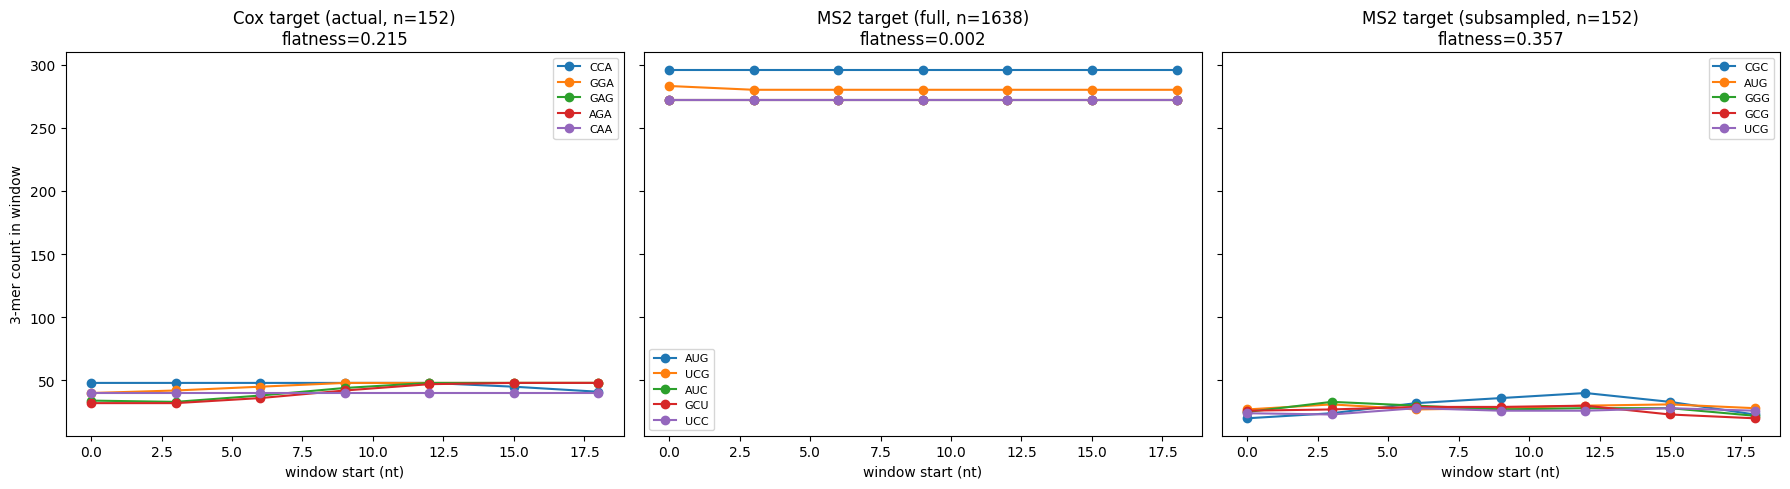

Saved: ms2_subsample_test.png


In [ ]:
# ============================================================
# Cell D — Visual: overlay a few subsampled MS2 draws against Cox and full MS2
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for km, vals in cox_target_data.items():
    axes[0].plot(cox_target_pos, vals, marker='o', label=km)
axes[0].set_title(f'Cox target (actual, n=152)\nflatness={cox_score:.3f}')
axes[0].set_xlabel('window start (nt)')
axes[0].set_ylabel('3-mer count in window')
axes[0].legend(fontsize=8)

for km, vals in ms2_target_data_full.items():
    axes[1].plot(ms2_target_pos, vals, marker='o', label=km)
axes[1].set_title(f'MS2 target (full, n=1638)\nflatness={ms2_full_score:.3f}')
axes[1].set_xlabel('window start (nt)')
axes[1].legend(fontsize=8)

random.seed(0)
ms2_sub_example = random.sample(ms2_target_seqs, 152)
pos_ex, data_ex = windowed_kmer_data(ms2_sub_example)
score_ex = flatness_score(pos_ex, data_ex)
for km, vals in data_ex.items():
    axes[2].plot(pos_ex, vals, marker='o', label=km)
axes[2].set_title(f'MS2 target (subsampled, n=152)\nflatness={score_ex:.3f}')
axes[2].set_xlabel('window start (nt)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('ms2_subsample_test.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: ms2_subsample_test.png")

In [ ]:
# ============================================================
# Cell E — THE CLEANER TEST: contiguous MS2 sub-regions (not scattered),
# matched in both sample size AND window contiguity to Cox
# ============================================================
import numpy as np
import random

N_TRIALS = 30
n_windows = 152  # match Cox's window count exactly

# ms2_target_seqs is assumed to be ordered by genomic position (built via
# sliding-window generation in order) -- this preserves adjacency structure
n_available = len(ms2_target_seqs)
max_start = n_available - n_windows

contiguous_scores = []
for trial in range(N_TRIALS):
    random.seed(trial)
    start = random.randint(0, max_start)
    ms2_contig_block = ms2_target_seqs[start : start + n_windows]
    pos, data = windowed_kmer_data(ms2_contig_block)
    contiguous_scores.append(flatness_score(pos, data))

contiguous_scores = np.array(contiguous_scores)
print(f"MS2 CONTIGUOUS sub-regions (n={n_windows} adjacent windows, {N_TRIALS} random start positions):")
print(f"  mean flatness score: {contiguous_scores.mean():.4f}")
print(f"  std:                 {contiguous_scores.std():.4f}")
print(f"  range:                {contiguous_scores.min():.4f} - {contiguous_scores.max():.4f}")
print()
print(f"For comparison:")
print(f"  Cox (actual, n=152, contiguous):        {cox_score:.4f}")
print(f"  MS2 full (n=1638):                      {ms2_full_score:.4f}")
print(f"  MS2 random scatter (n=152, 20 trials):  {subsample_scores.mean():.4f}")
print(f"  MS2 CONTIGUOUS block (n=152, 30 trials): {contiguous_scores.mean():.4f}")
print()

if abs(contiguous_scores.mean() - cox_score) < contiguous_scores.std():
    print("→ MS2 contiguous blocks land within one std of Cox's actual score.")
    print("  This is much stronger evidence for the sample-size explanation:")
    print("  with BOTH sample size and window contiguity matched, MS2 and Cox")
    print("  show similar positional variation.")
elif contiguous_scores.mean() < cox_score:
    print("→ MS2 contiguous blocks are still flatter than Cox even at matched")
    print("  sample size AND contiguity. This weakens the sample-size explanation")
    print("  and points toward a genuine sequence-level difference between the")
    print("  two viral regions.")
else:
    print("→ MS2 contiguous blocks show MORE variation than Cox even at matched")
    print("  sample size and contiguity.")

MS2 CONTIGUOUS sub-regions (n=152 adjacent windows, 30 random start positions):
  mean flatness score: 0.1220
  std:                 0.0456
  range:                0.0391 - 0.2329

For comparison:
  Cox (actual, n=152, contiguous):        0.2154
  MS2 full (n=1638):                      0.0021
  MS2 random scatter (n=152, 20 trials):  0.4052
  MS2 CONTIGUOUS block (n=152, 30 trials): 0.1220

→ MS2 contiguous blocks are still flatter than Cox even at matched
  sample size AND contiguity. This weakens the sample-size explanation
  and points toward a genuine sequence-level difference between the
  two viral regions.


In [ ]:
# ============================================================
# Cell F — Statistical comparison: is Cox's score plausibly drawn from
# the same distribution as MS2 contiguous blocks?
# ============================================================
from scipy import stats

# One-sample test: where does Cox's single actual value fall in the
# distribution of MS2 contiguous-block scores?
percentile = (contiguous_scores < cox_score).mean() * 100
print(f"Cox's actual flatness score ({cox_score:.4f}) sits at the "
      f"{percentile:.0f}th percentile of the MS2 contiguous-block distribution.")
print(f"(50th percentile = perfectly typical; <10 or >90 = clearly atypical)")
print()

z = (cox_score - contiguous_scores.mean()) / contiguous_scores.std()
print(f"Z-score of Cox relative to MS2 contiguous-block distribution: {z:.2f}")
print(f"(|z| < 2 is broadly consistent with Cox being a typical draw from")
print(f" the same underlying process as MS2's contiguous sub-regions)")

Cox's actual flatness score (0.2154) sits at the 97th percentile of the MS2 contiguous-block distribution.
(50th percentile = perfectly typical; <10 or >90 = clearly atypical)

Z-score of Cox relative to MS2 contiguous-block distribution: 2.05
(|z| < 2 is broadly consistent with Cox being a typical draw from
 the same underlying process as MS2's contiguous sub-regions)


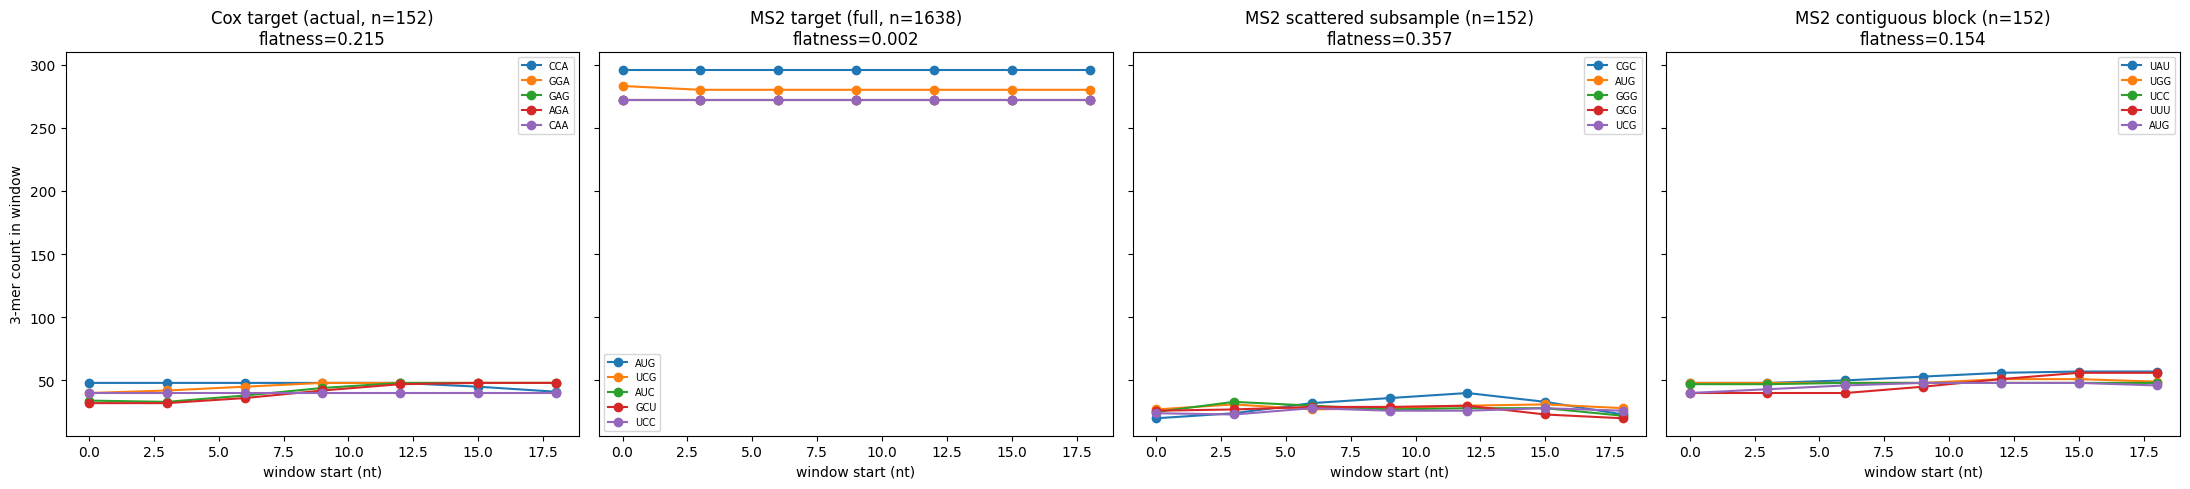

Saved: ms2_contiguous_vs_scattered_test.png


In [ ]:
# ============================================================
# Cell G — Updated 4-panel visual comparison
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

for km, vals in cox_target_data.items():
    axes[0].plot(cox_target_pos, vals, marker='o', label=km)
axes[0].set_title(f'Cox target (actual, n=152)\nflatness={cox_score:.3f}')
axes[0].set_ylabel('3-mer count in window')
axes[0].legend(fontsize=7)

for km, vals in ms2_target_data_full.items():
    axes[1].plot(ms2_target_pos, vals, marker='o', label=km)
axes[1].set_title(f'MS2 target (full, n=1638)\nflatness={ms2_full_score:.3f}')
axes[1].legend(fontsize=7)

random.seed(0)
ms2_scatter_example = random.sample(ms2_target_seqs, 152)
pos_sc, data_sc = windowed_kmer_data(ms2_scatter_example)
score_sc = flatness_score(pos_sc, data_sc)
for km, vals in data_sc.items():
    axes[2].plot(pos_sc, vals, marker='o', label=km)
axes[2].set_title(f'MS2 scattered subsample (n=152)\nflatness={score_sc:.3f}')
axes[2].legend(fontsize=7)

random.seed(0)
start_ex = random.randint(0, max_start)
ms2_contig_example = ms2_target_seqs[start_ex : start_ex + 152]
pos_cn, data_cn = windowed_kmer_data(ms2_contig_example)
score_cn = flatness_score(pos_cn, data_cn)
for km, vals in data_cn.items():
    axes[3].plot(pos_cn, vals, marker='o', label=km)
axes[3].set_title(f'MS2 contiguous block (n=152)\nflatness={score_cn:.3f}')
axes[3].legend(fontsize=7)

for ax in axes:
    ax.set_xlabel('window start (nt)')

plt.tight_layout()
plt.savefig('ms2_contiguous_vs_scattered_test.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: ms2_contiguous_vs_scattered_test.png")